**Bienes raíces - Ejemplos en Python**
==
*Magister Jorge Córdoba*
===
### Cualquier duda sobre estos códigos o querés profundizar sobre los mismos, escribime por MD a **@cefcapacitar**


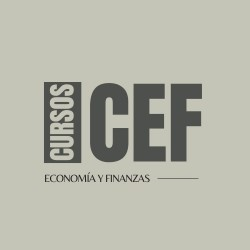

# 🏢 Primera parte
## Cinco Ejemplos Prácticos Automatizados en Python

---

Este notebook contiene **cinco ejercicios prácticos** que simulan situaciones reales del mercado inmobiliario y pueden automatizarse con Python:

| # | Ejemplo | Tema del módulo |
|---|---------|----------------|
| 1 | Clasificador automático de segmento inmobiliario | Segmentación del mercado |
| 2 | Simulador de financiamiento combinado | Fuentes de financiamiento |
| 3 | Evaluador de índice de oficinas premium | Mercado comercial |
| 4 | Analizador Build-to-Rent vs. venta tradicional | Diversificación residencial |
| 5 | Dashboard de actores del mercado | Actores clave |

> **Instrucciones:** Ejecutá cada celda en orden con `Shift + Enter`. Los ejemplos son independientes entre sí.


## 📦 Instalación de librerías necesarias
Ejecutar esta celda primero.

In [ ]:
!pip install pandas numpy matplotlib seaborn plotly -q
print("✅ Librerías instaladas correctamente.")

---
# 🏠 Ejemplo 1: Clasificador Automático de Segmento Inmobiliario

## Contexto
La corredora **Valentina Ríos** trabaja para la inmobiliaria **Clave Sur Propiedades** en Rosario.
Recibe una base de datos con 12 propiedades que el fondo **Meridian Asset Group** quiere analizar
antes de decidir en qué segmentos invertir.

El clasificador asigna automáticamente el segmento de mercado a cada propiedad según sus atributos:

- **Premium**: precio > USD 3.000/m², localización exclusiva
- **Affordable Housing**: precio ≤ USD 1.500/m², orientado a clase media
- **Segunda Vivienda**: ubicación turística
- **Build to Rent (BTR)**: destinado a alquiler institucional de largo plazo
- **Comercial Oficinas**: uso corporativo
- **Logístico / Industrial**: depósitos, centros de distribución, parques industriales
- **Alternativo**: hotelero, data centers, agroindustrial

### ¿Qué automatiza?
- Clasificación basada en reglas condicionales con `pandas`
- Asignación de nivel de riesgo por segmento
- Visualización del portafolio con gráfico de torta y barras horizontales

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
#  BASE DE DATOS SIMULADA — CLAVE SUR PROPIEDADES
# ─────────────────────────────────────────────
propiedades = [
    {"id": "P-001", "nombre": "Torre Catalinas Signature",     "precio_m2_usd": 4500, "uso": "residencial",  "zona": "urbana_premium",   "destino": "venta"},
    {"id": "P-002", "nombre": "Conjunto Habitar Verde",         "precio_m2_usd": 1100, "uso": "residencial",  "zona": "urbana_media",     "destino": "venta"},
    {"id": "P-003", "nombre": "Chalets Rincón del Faro",        "precio_m2_usd": 2200, "uso": "residencial",  "zona": "turistica",        "destino": "venta"},
    {"id": "P-004", "nombre": "Residencial Morada Activa",      "precio_m2_usd": 1900, "uso": "residencial",  "zona": "urbana_media",     "destino": "alquiler_institucional"},
    {"id": "P-005", "nombre": "Parque Industrial CentroLógico", "precio_m2_usd":  890, "uso": "industrial",   "zona": "periurbana",       "destino": "alquiler_largo_plazo"},
    {"id": "P-006", "nombre": "Piso Corporativo Palermo Tech",  "precio_m2_usd": 3400, "uso": "comercial",    "zona": "urbana_premium",   "destino": "alquiler_corporativo"},
    {"id": "P-007", "nombre": "Penthouses Belgrano Alto",       "precio_m2_usd": 3800, "uso": "residencial",  "zona": "urbana_premium",   "destino": "venta"},
    {"id": "P-008", "nombre": "Nave Last Mile Sur GBA",         "precio_m2_usd":  750, "uso": "logistico",    "zona": "periurbana",       "destino": "alquiler_largo_plazo"},
    {"id": "P-009", "nombre": "Dúplex Barrio Esperanza",        "precio_m2_usd": 1300, "uso": "residencial",  "zona": "urbana_media",     "destino": "venta"},
    {"id": "P-010", "nombre": "Boutique Hotel Punta Chica",     "precio_m2_usd": 2700, "uso": "hotelero",     "zona": "turistica",        "destino": "alquiler_vacacional"},
    {"id": "P-011", "nombre": "Hub Digital NOA Servers",        "precio_m2_usd": 5800, "uso": "data_center",  "zona": "urbana_premium",   "destino": "alquiler_corporativo"},
    {"id": "P-012", "nombre": "Apartamentos Vínculo Norte",     "precio_m2_usd": 2100, "uso": "residencial",  "zona": "urbana_media",     "destino": "alquiler_institucional"},
]

df = pd.DataFrame(propiedades)

# ─────────────────────────────────────────────
#  FUNCIÓN CLASIFICADORA
# ─────────────────────────────────────────────
def clasificar_segmento(row):
    """Clasifica una propiedad en su segmento de mercado."""
    uso, precio, zona, destino = row["uso"], row["precio_m2_usd"], row["zona"], row["destino"]

    if uso in ["logistico", "industrial"]:
        return "Logístico / Industrial"
    if uso == "data_center":
        return "Alternativo — Data Center"
    if uso == "hotelero":
        return "Alternativo — Hotelero"
    if uso == "comercial":
        return "Comercial Oficinas Premium"
    if destino == "alquiler_institucional":
        return "Build to Rent (BTR)"
    if zona == "turistica":
        return "Segunda Vivienda"
    if precio > 3000:
        return "Residencial Premium"
    if precio <= 1500:
        return "Affordable Housing"
    return "Residencial Medio"

def riesgo_segmento(seg):
    tabla = {
        "Residencial Premium":       "Bajo-Medio",
        "Affordable Housing":         "Medio",
        "Segunda Vivienda":           "Medio-Alto",
        "Build to Rent (BTR)":        "Bajo",
        "Comercial Oficinas Premium": "Medio",
        "Logístico / Industrial":     "Bajo",
        "Alternativo — Hotelero":     "Alto",
        "Alternativo — Data Center":  "Bajo",
        "Residencial Medio":          "Medio",
    }
    return tabla.get(seg, "No clasificado")

df["segmento"] = df.apply(clasificar_segmento, axis=1)
df["riesgo"]   = df["segmento"].apply(riesgo_segmento)

# ─────────────────────────────────────────────
#  RESULTADOS EN CONSOLA
# ─────────────────────────────────────────────
print("═" * 72)
print("   CLASIFICADOR DE SEGMENTOS — CLAVE SUR PROPIEDADES")
print("═" * 72)
print(df[["id", "nombre", "precio_m2_usd", "segmento", "riesgo"]].to_string(index=False))

# ─────────────────────────────────────────────
#  VISUALIZACIÓN
# ─────────────────────────────────────────────
colores = {
    "Residencial Premium":       "#2E4057",
    "Affordable Housing":         "#537D8D",
    "Segunda Vivienda":           "#8AB4C2",
    "Build to Rent (BTR)":        "#3A7D44",
    "Comercial Oficinas Premium": "#E07B39",
    "Logístico / Industrial":     "#C5392A",
    "Alternativo — Hotelero":     "#9B59B6",
    "Alternativo — Data Center":  "#1A535C",
    "Residencial Medio":          "#6DAEDB",
}

conteo        = df["segmento"].value_counts()
colores_graf  = [colores.get(s, "#AAAAAA") for s in conteo.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Clasificación de Portafolio — Clave Sur Propiedades / Meridian Asset Group",
             fontsize=12, fontweight="bold")

axes[0].pie(conteo.values, labels=conteo.index, colors=colores_graf,
            autopct="%1.0f%%", startangle=140, textprops={"fontsize": 8})
axes[0].set_title("Distribución por segmento", fontsize=11)

df_sorted  = df.sort_values("precio_m2_usd", ascending=True)
bar_colors = [colores.get(s, "#AAAAAA") for s in df_sorted["segmento"]]
axes[1].barh(df_sorted["nombre"], df_sorted["precio_m2_usd"],
             color=bar_colors, edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Precio USD/m²")
axes[1].set_title("Precio por m² por propiedad", fontsize=11)
axes[1].axvline(x=1500, color="#537D8D", linestyle="--", linewidth=1, label="Límite Affordable")
axes[1].axvline(x=3000, color="#2E4057", linestyle="--", linewidth=1, label="Límite Premium")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()
print("\n✅ Clasificación completada.", df['segmento'].nunique(), "segmentos identificados.")

---
# 💰 Ejemplo 2: Simulador de Financiamiento Combinado

## Contexto
**Constructora Horizonte Sur S.A.** necesita financiar su nuevo proyecto **Residencial Solana**
(un complejo de departamentos sustentables en Mendoza) por un total de **USD 4.800.000**.
El directorio evalúa cuatro fuentes posibles de capital:

1. **Ventas anticipadas (preventa)** → Inversores locales a través de fideicomiso
2. **Crowdfunding inmobiliario** → Plataforma digital para inversores de distintas regiones
3. **Fondo de inversión cerrado** → Capital institucional regulado
4. **Crédito bancario** → Financiamiento tradicional con garantía hipotecaria

El simulador calcula el **WACC** (costo ponderado de capital), la **utilidad neta estimada**
y genera un **ranking de escenarios** combinados según rentabilidad y accesibilidad.

### ¿Qué automatiza?
- Cálculo del WACC para distintas mezclas de financiamiento
- Score ponderado (60% rentabilidad + 40% accesibilidad al fondeo)
- Gráfico de barras + dispersión costo vs. accesibilidad

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
#  PARÁMETROS DEL PROYECTO
# ─────────────────────────────────────────────
PRESUPUESTO_TOTAL = 4_800_000
RETORNO_VENTAS    = 0.28        # retorno bruto estimado: 28% sobre capital invertido

fuentes = {
    "Preventa":             {"descripcion": "Inversores locales, fideicomiso",         "tasa": 0.09, "accesibilidad": 0.62},
    "Crowdfunding":         {"descripcion": "Plataforma digital, inversores globales",  "tasa": 0.13, "accesibilidad": 0.78},
    "Fondo Cerrado":        {"descripcion": "Capital institucional regulado",           "tasa": 0.16, "accesibilidad": 0.48},
    "Crédito Bancario":     {"descripcion": "Préstamo con garantía hipotecaria",        "tasa": 0.19, "accesibilidad": 0.33},
}

# ─────────────────────────────────────────────
#  ESCENARIOS DE MEZCLA
# ─────────────────────────────────────────────
escenarios = [
    {"nombre": "Solo Preventa",          "Preventa": 1.00, "Crowdfunding": 0.00, "Fondo Cerrado": 0.00, "Crédito Bancario": 0.00},
    {"nombre": "Clásico Bancario",       "Preventa": 0.40, "Crowdfunding": 0.00, "Fondo Cerrado": 0.00, "Crédito Bancario": 0.60},
    {"nombre": "Digital + Fondo",        "Preventa": 0.20, "Crowdfunding": 0.30, "Fondo Cerrado": 0.50, "Crédito Bancario": 0.00},
    {"nombre": "Mixto Equilibrado ★",    "Preventa": 0.30, "Crowdfunding": 0.20, "Fondo Cerrado": 0.50, "Crédito Bancario": 0.00},
    {"nombre": "Institucional Puro",     "Preventa": 0.00, "Crowdfunding": 0.00, "Fondo Cerrado": 0.65, "Crédito Bancario": 0.35},
    {"nombre": "Todo Crowdfunding",      "Preventa": 0.00, "Crowdfunding": 1.00, "Fondo Cerrado": 0.00, "Crédito Bancario": 0.00},
]

# ─────────────────────────────────────────────
#  CÁLCULO POR ESCENARIO
# ─────────────────────────────────────────────
def calcular_escenario(esc):
    wacc         = sum(esc.get(f, 0) * fuentes[f]["tasa"]          for f in fuentes)
    accesibilidad= sum(esc.get(f, 0) * fuentes[f]["accesibilidad"] for f in fuentes)
    costo_cap    = PRESUPUESTO_TOTAL * wacc
    utilidad     = PRESUPUESTO_TOTAL * RETORNO_VENTAS - costo_cap
    roi          = (utilidad / PRESUPUESTO_TOTAL) * 100
    return {
        "Escenario":           esc["nombre"],
        "WACC (%)": round(wacc * 100, 2),
        "Costo Capital (USD)": int(costo_cap),
        "Utilidad Neta (USD)": int(utilidad),
        "ROI Neto (%)": round(roi, 2),
        "Accesibilidad (%)": round(accesibilidad * 100, 1),
    }

resultados = pd.DataFrame([calcular_escenario(e) for e in escenarios])
resultados["Score"] = resultados["ROI Neto (%)"] * 0.6 + resultados["Accesibilidad (%)"] * 0.4
resultados = resultados.sort_values("Score", ascending=False).reset_index(drop=True)
resultados.index += 1

print("═" * 80)
print("  SIMULADOR DE FINANCIAMIENTO — RESIDENCIAL SOLANA | USD 4.800.000")
print("═" * 80)
print(resultados.drop(columns="Score").to_string())
print("\n★ = escenario recomendado para análisis principal")

# ─────────────────────────────────────────────
#  VISUALIZACIÓN
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
fig.suptitle("Análisis de Escenarios de Financiamiento — Residencial Solana",
             fontsize=12, fontweight="bold")

colores_bar = ["#2E4057" if "★" in e else "#537D8D" for e in resultados["Escenario"]]
nombres_c   = [e.replace(" ★", "") for e in resultados["Escenario"]]

ax1.barh(nombres_c, resultados["ROI Neto (%)"], color=colores_bar, edgecolor="white")
ax1.axvline(x=0, color="gray", linewidth=0.8)
ax1.set_xlabel("ROI Neto (%)")
ax1.set_title("Retorno neto por escenario")
for i, v in enumerate(resultados["ROI Neto (%)"]):
    ax1.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=8)

ax2.scatter(resultados["WACC (%)"], resultados["Accesibilidad (%)"],
            s=200, color=colores_bar, zorder=5, edgecolors="white", linewidths=1.5)
for i, row in resultados.iterrows():
    ax2.annotate(nombres_c[i-1], (row["WACC (%)"], row["Accesibilidad (%)"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=7)
ax2.set_xlabel("Costo de Capital — WACC (%)")
ax2.set_ylabel("Accesibilidad al fondeo (%)")
ax2.set_title("Costo vs. Accesibilidad")
ax2.grid(True, alpha=0.3)

leg = [mpatches.Patch(color="#2E4057", label="Escenario recomendado"),
       mpatches.Patch(color="#537D8D", label="Otros escenarios")]
ax2.legend(handles=leg, fontsize=8)

plt.tight_layout()
plt.show()
print("\n✅ Mejor escenario por score ponderado:", resultados.loc[1, 'Escenario'])

---
# 📊 Ejemplo 3: Evaluador de Índice de Oficinas Premium — América Latina

## Contexto
La consultora **Andina Real Estate Analytics** realiza un seguimiento semestral del mercado
de oficinas premium en América Latina para sus clientes institucionales.
Utilizan un índice compuesto (0–100 puntos) que combina:
- Percepción actual del mercado (encuesta a expertos)
- Expectativas para el semestre siguiente
- Datos duros: vacancia y precio de alquiler

El sistema calcula automáticamente:
- La **correlación predictiva** entre expectativas y situación real
- El **error promedio de predicción** del índice
- Alertas de fase de mercado (Contracción / Estabilización / Recuperación / Expansión)

### ¿Qué automatiza?
- Series temporales con `pandas` y `numpy`
- Cálculo de correlación entre expectativas desplazadas y resultados reales
- Sistema de alertas con umbrales configurables
- Gráfico de evolución dual (índice + vacancia/alquiler)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
#  DATOS HISTÓRICOS DEL ÍNDICE (2020–2025)
#  Semestres s1 = enero-junio, s2 = julio-diciembre
# ─────────────────────────────────────────────
datos_index = [
    {"semestre": "2020-S1", "actual": -11.0, "expectativas":  -7.5, "vacancia": 17.8, "alquiler": 19.0},
    {"semestre": "2020-S2", "actual":  -7.5, "expectativas":  -2.5, "vacancia": 20.9, "alquiler": 17.2},
    {"semestre": "2021-S1", "actual":  -3.0, "expectativas":   3.0, "vacancia": 21.5, "alquiler": 16.5},
    {"semestre": "2021-S2", "actual":   3.5, "expectativas":   8.0, "vacancia": 19.2, "alquiler": 17.8},
    {"semestre": "2022-S1", "actual":   8.2, "expectativas":  13.0, "vacancia": 16.8, "alquiler": 18.5},
    {"semestre": "2022-S2", "actual":  13.0, "expectativas":  17.5, "vacancia": 14.7, "alquiler": 20.0},
    {"semestre": "2023-S1", "actual":  17.8, "expectativas":  22.0, "vacancia": 12.9, "alquiler": 21.5},
    {"semestre": "2023-S2", "actual":  21.5, "expectativas":  24.5, "vacancia": 11.8, "alquiler": 23.0},
    {"semestre": "2024-S1", "actual":  24.0, "expectativas":  26.5, "vacancia": 11.0, "alquiler": 24.2},
    {"semestre": "2024-S2", "actual":  25.8, "expectativas":  27.2, "vacancia": 10.3, "alquiler": 25.0},
    {"semestre": "2025-S1", "actual":  27.0, "expectativas":  28.5, "vacancia":  9.5, "alquiler": 25.8},
]

df_idx = pd.DataFrame(datos_index)

# ─────────────────────────────────────────────
#  ANÁLISIS DE CAPACIDAD PREDICTIVA
# ─────────────────────────────────────────────
df_idx["expectativas_lag"] = df_idx["expectativas"].shift(1)
df_analisis  = df_idx.dropna(subset=["expectativas_lag"])
correlacion  = np.corrcoef(df_analisis["actual"], df_analisis["expectativas_lag"])[0, 1]
error_medio  = (df_analisis["actual"] - df_analisis["expectativas_lag"]).abs().mean()

# ─────────────────────────────────────────────
#  SISTEMA DE ALERTAS DE FASE
# ─────────────────────────────────────────────
def fase_mercado(v):
    if v < 0:   return "🔴 Contracción"
    if v < 10:  return "🟡 Estabilización"
    if v < 20:  return "🟢 Recuperación"
    return              "🔵 Expansión"

df_idx["fase"] = df_idx["actual"].apply(fase_mercado)

# ─────────────────────────────────────────────
#  REPORTE EJECUTIVO
# ─────────────────────────────────────────────
print("═" * 70)
print("   ÍNDICE DE OFICINAS PREMIUM — ANDINA REAL ESTATE ANALYTICS")
print("═" * 70)
print(df_idx[["semestre", "actual", "expectativas", "vacancia", "alquiler", "fase"]]
      .rename(columns={"actual": "Índice Real", "expectativas": "Expectativa",
                        "vacancia": "Vacancia %",  "alquiler": "Alquiler USD/m²"})
      .to_string(index=False))

print(f"\n📈 Análisis de capacidad predictiva:")
print(f"   • Correlación (expectativa → real, 6 meses después): {correlacion:.3f}")
print(f"   • Error promedio de predicción: {error_medio:.2f} puntos")
print(f"   • Calidad predictiva: {'Alta ✔' if correlacion > 0.95 else 'Media'}")

ultimo = df_idx.iloc[-1]
print(f"\n📍 Situación actual ({ultimo['semestre']}):")
print(f"   • Índice: {ultimo['actual']} pts | Próxima expectativa: {ultimo['expectativas']} pts")
print(f"   • Fase: {ultimo['fase']} | Vacancia: {ultimo['vacancia']}% | Alquiler: USD {ultimo['alquiler']}/m²")

# ─────────────────────────────────────────────
#  VISUALIZACIÓN
# ─────────────────────────────────────────────
x      = list(range(len(df_idx)))
labels = df_idx["semestre"].tolist()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Índice de Oficinas Premium — Evolución Latinoamérica (2020–2025)",
             fontsize=12, fontweight="bold")

axes[0].plot(x, df_idx["actual"],       "o-", color="#2E4057", lw=2,   label="Índice real",       ms=6)
axes[0].plot(x, df_idx["expectativas"], "s--",color="#537D8D", lw=1.5, label="Expectativa",       ms=5)
axes[0].plot(x[1:], df_analisis["expectativas_lag"].tolist(),
             "v:", color="#E07B39", lw=1.5, label="Expectativa desplazada (t-1)", ms=5)
for y_val, col, lbl in [(0, "red", "Contracción"), (10, "orange", "Estabilización"), (20, "green", "Expansión")]:
    axes[0].axhline(y=y_val, color=col, linestyle="-", lw=0.7, alpha=0.4)
axes[0].set_ylabel("Puntos del índice")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(x, 0, df_idx["actual"],
                      where=[v < 0 for v in df_idx["actual"]], alpha=0.15, color="red")

color_v, color_a = "#C5392A", "#3A7D44"
ax2b = axes[1].twinx()
axes[1].bar(x, df_idx["vacancia"], color=color_v, alpha=0.6, label="Vacancia (%)", width=0.4, align="edge")
ax2b.plot(x, df_idx["alquiler"],   "D-", color=color_a, lw=2, label="Alquiler USD/m²", ms=5)
axes[1].set_ylabel("Vacancia (%)", color=color_v)
ax2b.set_ylabel("Alquiler (USD/m²)", color=color_a)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
axes[1].grid(True, alpha=0.2)
l1, lb1 = axes[1].get_legend_handles_labels()
l2, lb2 = ax2b.get_legend_handles_labels()
axes[1].legend(l1 + l2, lb1 + lb2, fontsize=8)

plt.tight_layout()
plt.show()
print(f"\n✅ Correlación predictiva: {correlacion:.3f} | Error medio: {error_medio:.2f} pts")

---
# 🏗️ Ejemplo 4: Comparador Build-to-Rent vs. Venta Tradicional

## Contexto
El fondo **Meridian Asset Group** debe decidir el modelo de negocio para su proyecto
**Conjunto Residencial Oasis** (90 unidades en Córdoba capital):

- **Modelo A — Venta tradicional**: construir y vender cada unidad individualmente
- **Modelo B — Build to Rent (BTR)**: construir, retener y alquilar institucionalmente a largo plazo

El script proyecta flujos de fondos a **10 años**, calcula el **VAN** y la **TIR** para cada modelo,
e incluye el **valor terminal** del activo BTR al final del horizonte de inversión.

### ¿Qué automatiza?
- Proyección anual de flujos con ajuste por inflación
- Cálculo del VAN (tasa 10%) y TIR mediante bisección numérica (sin librerías externas)
- Valor terminal BTR vía múltiplo de renta
- Gráfico de recuperación acumulada + comparación de métricas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
#  PARÁMETROS DEL PROYECTO
# ─────────────────────────────────────────────
INVERSION_INICIAL  = 3_500_000   # USD costo de construcción
UNIDADES           = 90
TASA_DESCUENTO     = 0.10
INFLACION_ANUAL    = 0.05
HORIZONTE          = 10

# Modelo A — Venta
PRECIO_VENTA_UNIDAD = 52_000     # USD/unidad
RITMO_VENTAS_ANUAL  = 18         # unidades/año (5 años para agotar stock)
COSTO_OP_A          = 90_000     # USD/año (corretaje, marketing, admin)

# Modelo B — BTR
ALQUILER_MENSUAL    = 580        # USD/unidad/mes
VACANCIA_INICIAL    = 0.10
COSTO_OP_B          = 130_000    # USD/año (gestión profesional de activos)
VALOR_TERMINAL_MULT = 12         # múltiplo de renta anual (cap rate ~8.3%)

# ─────────────────────────────────────────────
#  PROYECCIÓN DE FLUJOS
# ─────────────────────────────────────────────
flujos_a, flujos_b  = [], []
unidades_vend_acum  = 0

for anio in range(1, HORIZONTE + 1):
    fi = (1 + INFLACION_ANUAL) ** (anio - 1)

    # Modelo A
    u_anio          = min(RITMO_VENTAS_ANUAL, UNIDADES - unidades_vend_acum)
    unidades_vend_acum += u_anio
    flujo_a         = u_anio * PRECIO_VENTA_UNIDAD * fi - COSTO_OP_A * fi
    flujos_a.append(round(flujo_a))

    # Modelo B
    vacancia  = max(0.02, VACANCIA_INICIAL - 0.01 * anio)
    ingresos  = UNIDADES * ALQUILER_MENSUAL * 12 * (1 - vacancia) * fi
    flujo_b   = ingresos - COSTO_OP_B * fi
    if anio == HORIZONTE:
        renta_term = UNIDADES * ALQUILER_MENSUAL * 12 * 0.95 * fi
        flujo_b   += renta_term * VALOR_TERMINAL_MULT
    flujos_b.append(round(flujo_b))

# ─────────────────────────────────────────────
#  VAN y TIR
# ─────────────────────────────────────────────
def van(flujos, inv, tasa):
    return -inv + sum(f / (1 + tasa) ** i for i, f in enumerate(flujos, 1))

def tir(flujos, inv):
    lo, hi = 0.0, 2.0
    for _ in range(1000):
        mid = (lo + hi) / 2
        if van(flujos, inv, mid) > 0: lo = mid
        else:                         hi = mid
        if abs(hi - lo) < 1e-5:      break
    return (lo + hi) / 2

van_a, van_b = van(flujos_a, INVERSION_INICIAL, TASA_DESCUENTO), van(flujos_b, INVERSION_INICIAL, TASA_DESCUENTO)
tir_a, tir_b = tir(flujos_a, INVERSION_INICIAL), tir(flujos_b, INVERSION_INICIAL)

# VAN acumulado
acum_a, acum_b = [-INVERSION_INICIAL], [-INVERSION_INICIAL]
for i, (fa, fb) in enumerate(zip(flujos_a, flujos_b), 1):
    acum_a.append(acum_a[-1] + fa / (1 + TASA_DESCUENTO) ** i)
    acum_b.append(acum_b[-1] + fb / (1 + TASA_DESCUENTO) ** i)

# ─────────────────────────────────────────────
#  TABLA Y REPORTE
# ─────────────────────────────────────────────
df_comp = pd.DataFrame({"Año": range(1, 11),
                         "Flujo Venta (USD)": flujos_a,
                         "Flujo BTR (USD)":   flujos_b})

print("═" * 68)
print("   BTR vs. VENTA TRADICIONAL — CONJUNTO OASIS | MERIDIAN ASSET GROUP")
print("═" * 68)
print(df_comp.to_string(index=False))
print("\n" + "─" * 68)
print(f"  {'Métrica':<30} {'Venta':>18} {'BTR':>15}")
print("─" * 68)
print(f"  {'VAN (USD)':<30} {van_a:>18,.0f} {van_b:>15,.0f}")
print(f"  {'TIR (%)':<30} {tir_a*100:>18.2f} {tir_b*100:>15.2f}")
print("─" * 68)
print(f"\n  🏆 Recomendación por VAN: {'Build to Rent' if van_b > van_a else 'Venta Tradicional'}")

# ─────────────────────────────────────────────
#  VISUALIZACIÓN
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("BTR vs. Venta Tradicional — Conjunto Oasis (Córdoba)",
             fontsize=12, fontweight="bold")

anios = list(range(HORIZONTE + 1))
axes[0].plot(anios, [v/1e6 for v in acum_a], "o-", color="#2E4057", lw=2, label="Venta")
axes[0].plot(anios, [v/1e6 for v in acum_b], "s-", color="#3A7D44", lw=2, label="BTR")
axes[0].axhline(y=0, color="gray", lw=0.8, linestyle="--")
axes[0].fill_between(anios, [v/1e6 for v in acum_a], [v/1e6 for v in acum_b],
                      alpha=0.1, color="#3A7D44")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("VAN acumulado (USD millones)")
axes[0].set_title("Recuperación de la inversión")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cats  = ["VAN (M USD)", "TIR (%)"]
va    = [van_a/1e6, tir_a*100]
vb    = [van_b/1e6, tir_b*100]
xp    = np.arange(2)
w     = 0.35
axes[1].bar(xp-w/2, va, w, label="Venta", color="#2E4057", alpha=0.85)
axes[1].bar(xp+w/2, vb, w, label="BTR",   color="#3A7D44", alpha=0.85)
axes[1].set_xticks(xp)
axes[1].set_xticklabels(cats)
axes[1].set_title("Métricas financieras")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")
for bar in axes[1].patches:
    axes[1].annotate(f"{bar.get_height():.2f}",
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()
print(f"\n✅ VAN BTR: USD {van_b:,.0f} | VAN Venta: USD {van_a:,.0f}")

---
# 🗺️ Ejemplo 5: Dashboard de Actores del Mercado Inmobiliario

## Contexto
La consultora **Andina Real Estate Analytics** debe presentar al directorio de **Meridian Asset Group**
un mapeo completo de los actores involucrados en su operación en la provincia de Córdoba.

El dashboard genera automáticamente:
1. Un **mapa de actores** con burbujas proporcionales al nivel de influencia
2. Un **grafo de interacciones** entre actores (flechas tipificadas por relación)
3. Un **reporte ejecutivo** automático con el rol de cada actor

### ¿Qué automatiza?
- Representación de redes de actores con `matplotlib`
- Flechas diferenciadas por tipo de relación (financiamiento, regulación, servicios, etc.)
- Generación automática de fichas descriptivas por actor
- Ranking de influencia relativa

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
#  ACTORES DEL MERCADO
# ─────────────────────────────────────────────
actores = [
    {"nombre": "Meridian Asset Group",      "tipo": "Inversor",      "influencia": 9,  "riesgo": "Bajo-Medio",  "x": 0.72, "y": 0.80},
    {"nombre": "Horizonte Sur S.A.",         "tipo": "Desarrollador", "influencia": 8,  "riesgo": "Medio-Alto",  "x": 0.40, "y": 0.70},
    {"nombre": "Grupo Constructor Ferrini",   "tipo": "Constructor",  "influencia": 6,  "riesgo": "Medio",        "x": 0.28, "y": 0.50},
    {"nombre": "Clave Sur Propiedades",       "tipo": "Corredor",     "influencia": 7,  "riesgo": "Bajo",         "x": 0.52, "y": 0.40},
    {"nombre": "Banco Provincial del Centro", "tipo": "Prestamista",  "influencia": 8,  "riesgo": "Bajo",         "x": 0.80, "y": 0.30},
    {"nombre": "Ente Regulador de Valores",   "tipo": "Regulador",    "influencia": 10, "riesgo": "—",            "x": 0.50, "y": 0.92},
    {"nombre": "Municipio Capital",           "tipo": "Regulador",    "influencia": 9,  "riesgo": "—",            "x": 0.20, "y": 0.90},
    {"nombre": "Compradores e Inquilinos",    "tipo": "Demanda",      "influencia": 7,  "riesgo": "Variable",     "x": 0.50, "y": 0.18},
    {"nombre": "Plataforma PropFund",         "tipo": "Inversor",     "influencia": 5,  "riesgo": "Medio",        "x": 0.82, "y": 0.60},
    {"nombre": "Tasadora Cer-Val",            "tipo": "Servicio",     "influencia": 4,  "riesgo": "Bajo",         "x": 0.20, "y": 0.30},
    {"nombre": "Proveedores Insumat S.A.",    "tipo": "Cadena Valor", "influencia": 5,  "riesgo": "Medio",        "x": 0.10, "y": 0.60},
    {"nombre": "Estudio Jurídico Peralta",    "tipo": "Servicio",     "influencia": 4,  "riesgo": "Bajo",         "x": 0.65, "y": 0.52},
]

# ─────────────────────────────────────────────
#  INTERACCIONES
# ─────────────────────────────────────────────
interacciones = [
    {"origen": "Meridian Asset Group",      "destino": "Horizonte Sur S.A.",         "tipo": "financiamiento"},
    {"origen": "Horizonte Sur S.A.",         "destino": "Grupo Constructor Ferrini",  "tipo": "contrato_obra"},
    {"origen": "Clave Sur Propiedades",      "destino": "Compradores e Inquilinos",   "tipo": "intermediacion"},
    {"origen": "Banco Provincial del Centro","destino": "Horizonte Sur S.A.",         "tipo": "credito"},
    {"origen": "Ente Regulador de Valores",  "destino": "Meridian Asset Group",       "tipo": "regulacion"},
    {"origen": "Municipio Capital",          "destino": "Horizonte Sur S.A.",         "tipo": "permisos"},
    {"origen": "Plataforma PropFund",        "destino": "Horizonte Sur S.A.",         "tipo": "financiamiento"},
    {"origen": "Tasadora Cer-Val",           "destino": "Banco Provincial del Centro","tipo": "valuacion"},
    {"origen": "Proveedores Insumat S.A.",   "destino": "Grupo Constructor Ferrini",  "tipo": "insumos"},
    {"origen": "Estudio Jurídico Peralta",   "destino": "Horizonte Sur S.A.",         "tipo": "asesoramiento"},
    {"origen": "Clave Sur Propiedades",      "destino": "Horizonte Sur S.A.",         "tipo": "comercializacion"},
]

colores_tipo = {
    "Inversor":      "#2E4057",
    "Desarrollador": "#E07B39",
    "Constructor":   "#C5392A",
    "Corredor":      "#3A7D44",
    "Prestamista":   "#537D8D",
    "Regulador":     "#9B59B6",
    "Demanda":       "#1A535C",
    "Servicio":      "#8AB4C2",
    "Cadena Valor":  "#F39C12",
}
colores_inter = {
    "financiamiento":  ("#2E4057", "solid"),
    "contrato_obra":   ("#C5392A", "dashed"),
    "intermediacion":  ("#3A7D44", "solid"),
    "credito":         ("#537D8D", "solid"),
    "regulacion":      ("#9B59B6", "dotted"),
    "permisos":        ("#9B59B6", "dotted"),
    "valuacion":       ("#8AB4C2", "dashed"),
    "insumos":         ("#F39C12", "dashed"),
    "asesoramiento":   ("#8AB4C2", "dotted"),
    "comercializacion":("#3A7D44", "dashed"),
}

# ─────────────────────────────────────────────
#  REPORTE EJECUTIVO
# ─────────────────────────────────────────────
rol_desc = {
    "Inversor":      "Aporta capital y define la orientación financiera del proyecto.",
    "Desarrollador": "Concibe, planifica y coordina desde la adquisición del suelo hasta la comercialización.",
    "Constructor":   "Ejecuta la obra según planos; gestiona subcontratistas y calidad de materiales.",
    "Corredor":      "Intermedia entre oferta y demanda; aporta ética profesional y seguridad jurídica.",
    "Prestamista":   "Provee capital de deuda; los bancos dan estructura, los fondos flexibilidad.",
    "Regulador":     "Establece marcos normativos, fiscales y de control que condicionan al mercado.",
    "Demanda":       "Usuarios finales; sus preferencias y solvencia determinan la absorción del proyecto.",
    "Servicio":      "Prestadores especializados que reducen asimetrías informativas (tasación, legal).",
    "Cadena Valor":  "Industrias vinculadas con fuerte efecto multiplicador en empleo e insumos.",
}

df_act = pd.DataFrame(actores)
print("═" * 70)
print("   MAPA DE ACTORES — MERIDIAN ASSET GROUP / CÓRDOBA")
print("═" * 70)
for _, row in df_act.sort_values("influencia", ascending=False).iterrows():
    estrellas = "★" * row["influencia"] + "☆" * (10 - row["influencia"])
    print(f"\n  {estrellas}  [{row['tipo']:15}] {row['nombre']}")
    print(f"  {'':22} Influencia: {row['influencia']}/10 | Riesgo: {row['riesgo']}")
    print(f"  {'':22} {rol_desc.get(row['tipo'], '')}")

# ─────────────────────────────────────────────
#  VISUALIZACIÓN
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Dashboard de Actores del Mercado Inmobiliario — Meridian Asset Group Córdoba",
             fontsize=12, fontweight="bold")

# Mapa de actores
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("← Producción / ejecución                  Capital / regulación →")
ax.set_ylabel("← Operativo                                    Estratégico →")
ax.set_title("Mapa de Actores por Rol e Influencia")
ax.grid(True, alpha=0.15)

xy = {a["nombre"]: (a["x"], a["y"]) for a in actores}
for inter in interacciones:
    x0, y0 = xy[inter["origen"]]
    x1, y1 = xy[inter["destino"]]
    col, sty = colores_inter.get(inter["tipo"], ("gray", "dashed"))
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color=col, lw=1.2,
                                linestyle=sty, connectionstyle="arc3,rad=0.1"))

for actor in actores:
    col  = colores_tipo.get(actor["tipo"], "gray")
    size = actor["influencia"] ** 2 * 30
    ax.scatter(actor["x"], actor["y"], s=size, color=col, alpha=0.85,
               edgecolors="white", linewidths=1.5, zorder=5)
    ax.annotate(actor["nombre"], (actor["x"], actor["y"]),
                textcoords="offset points", xytext=(8, 5), fontsize=6.5)

leyenda = [mpatches.Patch(color=v, label=k) for k, v in colores_tipo.items()]
ax.legend(handles=leyenda, fontsize=6.5, loc="lower right",
          title="Tipo de actor", title_fontsize=7)

# Ranking de influencia
ax2 = axes[1]
df_ord = df_act.sort_values("influencia", ascending=True)
bar_c  = [colores_tipo.get(t, "gray") for t in df_ord["tipo"]]
ax2.barh(df_ord["nombre"], df_ord["influencia"], color=bar_c, edgecolor="white", alpha=0.88)
ax2.set_xlabel("Nivel de influencia (1–10)")
ax2.set_title("Ranking de influencia relativa")
ax2.set_xlim(0, 11)
ax2.axvline(x=7, color="gray", linestyle="--", lw=0.8, alpha=0.6, label="Umbral alto")
ax2.legend(fontsize=8)
for i, (v, _) in enumerate(zip(df_ord["influencia"], df_ord["nombre"])):
    ax2.text(v + 0.1, i, str(v), va="center", fontsize=8)
ax2.tick_params(axis="y", labelsize=7.5)
ax2.grid(True, alpha=0.2, axis="x")

plt.tight_layout()
plt.show()
print(f"\n✅ Mapeados {len(actores)} actores y {len(interacciones)} interacciones.")
print("   Actor de mayor influencia:",
      df_act.sort_values('influencia', ascending=False).iloc[0]['nombre'])

---
## 📋 Resumen Integrador

| # | Ejemplo | Actores ficticios | Herramientas Python | Tema |
|---|---------|-------------------|---------------------|--------------------|
| 1 | Clasificador de segmentos | Valentina Ríos · Clave Sur · Meridian Asset | `pandas` + reglas + `matplotlib` | Segmentación del mercado |
| 2 | Simulador de financiamiento | Horizonte Sur · Residencial Solana | WACC + scoring + `gridspec` | Fuentes de financiamiento |
| 3 | Evaluador índice de oficinas | Andina Real Estate Analytics | Series temporales + correlación | Mercado comercial |
| 4 | BTR vs. Venta tradicional | Meridian · Conjunto Oasis | VAN + TIR numérica + flujos | Diversificación residencial |
| 5 | Dashboard de actores | Ferrini · Cer-Val · PropFund · Peralta | Grafos + burbujas + ranking | Actores clave |

